# Data Classification

Tugas ketiga menyusun klasifikasi berita pada data crawl. Alurnya meniru kanvas
Orange: data diimpor, dimensi dikecilkan dengan PCA, model Naive Bayes dan KNN
dilatih, lalu keduanya dibandingkan lewat *test and score* yang memakai
cross-validation. Seluruh langkah ditulis ulang dengan scikit-learn dengan
harapan setiap tahap bisa diamati dan hasilnya diperiksa ulang.


In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report

import matplotlib.pyplot as plt
%matplotlib inline


## Data Import

Data berita hasil crawl dimuat dari berkas `crawling_detik.csv`. Kolom teks
berita dipakai sebagai fitur dan kolom `label` menjadi kelas yang diprediksi.
Sebelum diproses lebih jauh, data diperiksa kelengkapannya dan keseimbangan
kelasnya.


In [2]:
DATA = "../../data/Web-Mining"
df = pd.read_csv(f"{DATA}/crawling_detik.csv")

checks = pd.DataFrame({
    "pemeriksaan": ["jumlah baris", "nilai kosong", "baris ganda",
                    "URL ganda", "urutan id", "label per kelas", "kelas"],
    "hasil": [len(df), df.isna().sum().sum(), df.duplicated().sum(),
              df["url"].duplicated().sum(),
              "lengkap 1-" + str(len(df)) if list(df["id"]) == list(range(1, len(df) + 1)) else "tidak urut",
              "; ".join(f"{k}: {v}" for k, v in df["label"].value_counts().items()),
              str(df["label"].dropna().unique().tolist())],
})
checks


,pemeriksaan,hasil
0,jumlah baris,200
1,nilai kosong,0
2,baris ganda,0
3,URL ganda,0
4,urutan id,lengkap 1-200
5,label per kelas,sport: 100; finance: 100
6,kelas,"['sport', 'finance']"


In [3]:
df["panjang"] = df["isi_berita"].str.len()
df.groupby("label")["panjang"].agg(["count", "min", "median", "mean", "max"])


,count,min,median,mean,max
label,,,,,
finance,100,1210,2501.0,2828.03,14106
sport,100,924,2409.0,2557.06,5809


## Word Vectors

Model tidak membaca teks mentah, jadi setiap berita diubah menjadi vektor
TF-IDF. Vektor ini berukuran sebesar kosakata unik dokumen sehingga sebelum
diklasifikasi, dimensinya dikecilkan dengan PCA. Pembobotan TF-IDF memberi nilai
rendah pada kata yang terlalu umum dan nilai tinggi pada kata khas sebuah
dokumen.


In [4]:
vec = TfidfVectorizer(min_df=2)
X = vec.fit_transform(df["isi_berita"])
X.shape


(200, 4092)

In [5]:
feature_names = vec.get_feature_names_out()
"kosakata: " + str(len(feature_names))


'kosakata: 4092'

## Component Reduction

Representasi TF-IDF bertipe sparse dengan ribuan term. Pengurangan dimensi
dilakukan dengan TruncatedSVD, varian PCA yang bekerja langsung pada matriks
sparse tanpa mengisinya dengan nol. Jumlah komponen dipilih dari kurva varians
kumulatif, bukan ditetapkan sembarangan.


In [6]:
full = min(X.shape) - 1
svd = TruncatedSVD(n_components=full, random_state=42)
svd.fit(X)
cum = np.cumsum(svd.explained_variance_ratio_)

targets = {}
for t in (0.2, 0.5, 0.8, 0.9, 0.95):
    targets.setdefault("ambang", []).append(t)
    targets.setdefault("komponen", []).append(int(np.argmax(cum >= t)) + 1)
    targets.setdefault("varians", []).append(round(float(cum[np.argmax(cum >= t)]), 4))
pd.DataFrame(targets)


,ambang,komponen,varians
0,0.20,10,0.2015
1,0.50,45,0.5050
2,0.80,109,0.8021
3,0.90,141,0.9006
4,0.95,162,0.9510


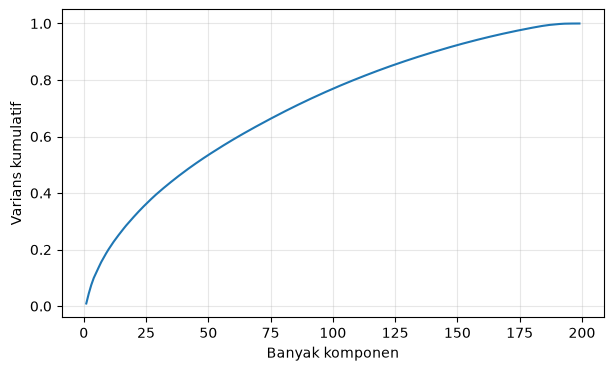

In [7]:
plt.figure(figsize=(7, 4))
plt.plot(np.arange(1, full + 1), cum)
plt.xlabel("Banyak komponen")
plt.ylabel("Varians kumulatif")
plt.grid(alpha=0.3)
plt.show()


In [8]:
n_comp = int(np.argmax(cum >= 0.9)) + 1
"komponen untuk 90% varians: " + str(n_comp)


'komponen untuk 90% varians: 141'

In [9]:
X_pca = svd.transform(X)[:, :n_comp]
X_pca.shape


(200, 141)

## Classification Models

Data tereduksi lalu dipisah menjadi set latih dan set uji. Dua model dilatih:

- **Naive Bayes Gaussian** — memilih kelas dari peluang maksimum dengan asumsi
  tiap komponen menyebar normal.
- **kNN** — memilih kelas dari tetangga terdekat; nilai `k` dipilih dengan
  cross-validation pada set latih.

Sebelum dipakai, komponen PCA distandarkan. Normalisasi ini penting untuk kNN
yang mengandalkan jarak; Naive Bayes ikut dilatih pada skala yang sama agar
perbandingannya adil.


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, df["label"], test_size=0.2, stratify=df["label"], random_state=42)
pd.Series({ "latih": len(y_train), "uji": len(y_test) })


latih    160
uji       40
dtype: int64

In [11]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
X_train_s.shape


(160, 141)

In [12]:
rownb = GaussianNB().fit(X_train_s, y_train)
"akurasi test NB: " + f"{rownb.score(X_test_s, y_test):.4f}"


'akurasi test NB: 1.0000'

In [13]:
k_cands = np.arange(1, 16)
scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_train_s, y_train,
                          cv=5, scoring="accuracy").mean() for k in k_cands]
best_k = int(k_cands[np.argmax(scores)])
pd.DataFrame({"k": k_cands, "akurasi": scores})


,k,akurasi
0,1,0.67500
1,2,0.74375
2,3,0.56875
3,4,0.63125
4,5,0.56250
5,6,0.63750
6,7,0.55000
7,8,0.57500
8,9,0.52500
9,10,0.53750


In [14]:
knn = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_s, y_train)
f"akurasi test kNN (k={best_k}): {knn.score(X_test_s, y_test):.4f}"


'akurasi test kNN (k=2): 0.7250'

## Test and Score

Evaluasi terakhir memakai cross-validation 10 lipatan berstrata, sama seperti
widget *Test and Score* pada Orange. Data dibagi sepuluh kali, model dilatih
pada sembilan lipatan dan diuji pada lipatan tersisa, lalu rata-ratanya
dirangkum per metrik. Angka yang dihasilkan tidak bergantung pada satu
pembagian data acak.


In [15]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score

y_b = y_train.map({"finance": 0, "sport": 1})
scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(precision_score, pos_label=1),
    "recall": make_scorer(recall_score, pos_label=1),
    "f1": make_scorer(f1_score, pos_label=1),
}
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
rows = []
for name, model in (("Naive Bayes", GaussianNB()),
                    ("kNN", KNeighborsClassifier(n_neighbors=best_k))):
    r = cross_validate(model, X_train_s, y_b, cv=cv, scoring=scoring)
    rows.append({
        "model": name,
        "accuracy": f"{r['test_accuracy'].mean():.3f} ± {r['test_accuracy'].std():.3f}",
        "precision": f"{r['test_precision'].mean():.3f} ± {r['test_precision'].std():.3f}",
        "recall": f"{r['test_recall'].mean():.3f} ± {r['test_recall'].std():.3f}",
        "f1": f"{r['test_f1'].mean():.3f} ± {r['test_f1'].std():.3f}",
    })
score_table = pd.DataFrame(rows)
score_table


,model,accuracy,precision,recall,f1
0,Naive Bayes,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000,1.000 ± 0.000
1,kNN,0.762 ± 0.100,0.696 ± 0.099,0.988 ± 0.037,0.812 ± 0.065


In [16]:
print(classification_report(y_test, rownb.predict(X_test_s)))


              precision    recall  f1-score   support

     finance       1.00      1.00      1.00        20
       sport       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



## Conclusion

Pipeline ala Orange berhasil dijalankan pada 200 berita yang terbagi rata
(100 sport, 100 finance). Kosakata TF-IDF berjumlah 4.092 term, dan 141 komponen
utama sudah merepresentasikan 90% varians (reduksi 96,6%). ***Naive Bayes
Gaussian mencapai skor sempurna 1,000*** pada set uji maupun 10-fold
cross-validation (akurasi 1,000 ± 0,000). ***kNN terbaik pada k=2*** dengan
akurasi test 0,725 dan hasil CV 0,762 ± 0,100; recall-nya tinggi (0,988) namun
precision-nya lebih rendah (0,696), menunjukkan prediksi berita sport agak
berlebihan. Untuk data ini Naive Bayes adalah pilihan utama karena ruang fitur
yang terpisah dengan jelas; kNN tetap berguna sebagai pembanding yang tidak
membuat asumsi distribusi.
